In [ ]:
!cat /etc/os-release
print()
!ls -a
!df -h
!free -h
!nvidia-smi

PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy

.  ..  .config	sample_data
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   43G   70G  39% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       119G   48G   72G  41% /kaggle/input
tmpfs           6.4G   92K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
               total        used        free      shared  buff/cache   available
Mem:           

In [9]:
# MNIST dataset으로 CNN 실습
import tensorflow as tf
print(tf.__version__) # 2.20.0
import numpy as np
import matplotlib.pyplot as plt

# 1) 데이터 준비
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train[0])
print(x_train.shape) # (60000, 28, 28)

# 채널(channel) 추가 (흑백인 경우 1)
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0  # 정규화
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print(x_train.shape) # (60000, 28, 28, 1)  # 3차원 -> 4차원



2.20.0
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253

In [20]:
# 2) 모델 정의
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(filters=16, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Flatten(),   # FCLayer(Fully Connnect Layer) : 1차원으로 구조 변경

    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.3),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=10, activation='softmax')

])
print(model.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,626 (420.41 KB)

 Trainable params: 107,626 (420.41 KB)

 Non-trainable params: 0 (0.00 B)

None


In [21]:
from IPython.core import history
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=100, batch_size=128, validation_split=0.1, callbacks=[es], verbose=1)



Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7936 - loss: 0.6397 - val_accuracy: 0.9688 - val_loss: 0.1061
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9370 - loss: 0.2191 - val_accuracy: 0.9803 - val_loss: 0.0698
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9552 - loss: 0.1576 - val_accuracy: 0.9828 - val_loss: 0.0604
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9629 - loss: 0.1333 - val_accuracy: 0.9865 - val_loss: 0.0488
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9673 - loss: 0.1158 - val_accuracy: 0.9870 - val_loss: 0.0452
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9709 - loss: 0.1027 - val_accuracy: 0.9892 - val_loss: 0.0465
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9741 - loss: 0.0951 - val_accuracy: 0.9883 - val_loss: 0.0447
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9764 - loss: 0.0851 - val_ac

In [22]:
# 모델 평가 : 아래 두개의 평가 점수의 차이가 크면 과적합 의심
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f"train_loss : {train_loss:.4f}, train_acc : {train_acc:.4f}")

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"test_loss : {test_loss:.4f}, test_acc : {test_acc:.4f}")

train_loss : 0.0198, train_acc : 0.9941
test_loss : 0.0294, test_acc : 0.9895


In [23]:
# 모델 저장 및 재로딩
SAVE_PATH = 'cnn1model.keras'
model.save(SAVE_PATH)
print(f"모델 저장 {SAVE_PATH}")

모델 저장 cnn1model.keras


In [24]:
loaded_model = tf.keras.models.load_model(SAVE_PATH)
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"[Reloaded]test_loss : {test_loss:.4f}, test_acc : {test_acc:.4f}")


[Reloaded]test_loss : 0.0294, test_acc : 0.9895


In [27]:
#  분류 예측 (편의상 기존 자료 사용)
idx = 0
x_one = x_test[idx:idx + 1]
y_true = int(y_test[idx])
# print(x_one)
# print(y_true)  # 7

probs = loaded_model.predict(x_one, verbose=0)[0]
print('probs :', probs)
y_pred = int(np.argmax(probs))
print(f"실제값 : {y_true}, 예측값 : {y_pred}")



probs : [3.2450067e-11 1.0544836e-09 5.3575980e-07 1.5346527e-07 1.9404643e-10
 1.3220557e-10 1.6038645e-13 9.9999905e-01 4.7409338e-10 2.9536494e-07]
실제값 : 7, 예측값 : 7


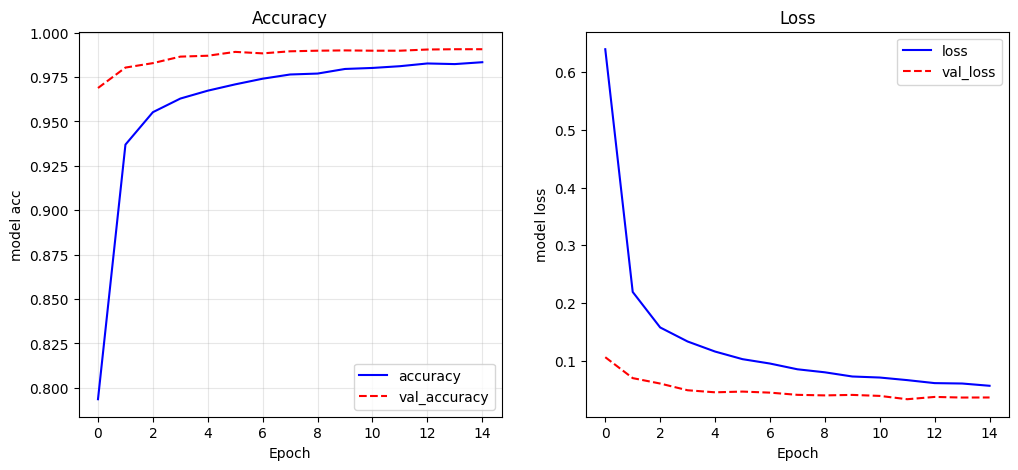

In [32]:
# 시각화
# 학습곡선 (정확도 / 손실)
# %matplotlib inline   # '%'매직명령어 중 matplotlib의 show() 처리  , vs code에서는 필요X

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'r--', label='val_accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('model acc')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('model loss')
plt.legend()
plt.show()

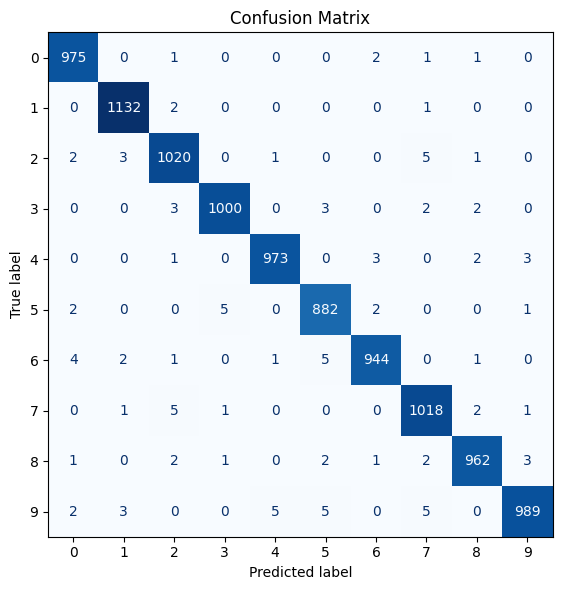

In [39]:
# 혼동 행렬 (confusion matrix) 출력
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_all = np.argmax(loaded_model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred_all, labels=list(range(10)))
# print(cm)

classes = [str(i) for i in range(10)]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()